# 02 Model Preperation
## Daten laden

In [1]:
import pandas as pd
from pathlib import Path

# Pfad zum Rohdatenordner
DATA_DIR = Path("../data/raw")

measures = pd.read_csv(DATA_DIR / "measures.csv", sep=";", decimal=",")
to_predict = pd.read_csv(DATA_DIR / "to_predict.csv", sep=";", decimal=",")

#Dimensionen anzeigen
print("Measures:", measures.shape)
print("To Predict:", to_predict.shape)

Measures: (7352, 563)
To Predict: (2947, 562)


## Subject-Spalte prüfen

In [3]:
print("Subject dtype in measures:", measures["subject"].dtype)
print("Subject dtype in to_predict:", to_predict["subject"].dtype)

print("Subjects in measures:", [int(s) for s in sorted(measures["subject"].unique())])
print("Subjects in to_predict:", [int(s) for s in sorted(to_predict["subject"].unique())])

Subject dtype in measures: float64
Subject dtype in to_predict: int64
Subjects in measures: [1, 3, 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 25, 26, 27, 28, 29, 30]
Subjects in to_predict: [2, 4, 9, 10, 12, 13, 18, 20, 24]


## Train/Test-Split nach Subjects


In [5]:
test_subjects = [27, 28, 29, 30]

train_data = measures[~measures["subject"].isin(test_subjects)].copy()
test_data = measures[measures["subject"].isin(test_subjects)].copy()

print("Train data:", train_data.shape)
print("Test data:", test_data.shape)

print("Train subjects:", [int(s) for s in sorted(train_data["subject"].unique())])
print("Test subjects:", [int(s) for s in sorted(test_data["subject"].unique())])

train_subjects = set(train_data["subject"].unique())
test_subjects_set = set(test_data["subject"].unique())

overlap = train_subjects.intersection(test_subjects_set)

required_train_subjects = {1, 3, 5, 6}

print("Überschneidungen zwischen Train und Test:", overlap)
print("Pflicht-Trainingssubjekte vorhanden:", required_train_subjects.issubset(train_subjects))


Train data: (5867, 563)
Test data: (1485, 563)
Train subjects: [1, 3, 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 25, 26]
Test subjects: [27, 28, 29, 30]
Überschneidungen zwischen Train und Test: set()
Pflicht-Trainingssubjekte vorhanden: True


## Features und Zielvariable

In [7]:
target_col = "activity"
group_col = "subject"

feature_cols = [col for col in train_data.columns if col not in [group_col, target_col]]

X_train = train_data[feature_cols]
y_train = train_data[target_col]
groups_train = train_data[group_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]

X_unseen = to_predict[feature_cols]

print("Anzahl Feature-Spalten:", len(feature_cols))

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("groups_train:", groups_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("X_unseen:", X_unseen.shape)

same_features = list(X_train.columns) == list(X_test.columns) == list(X_unseen.columns)
print("Gleiche Features in allen Datensätzen:", same_features)

Anzahl Feature-Spalten: 561
X_train: (5867, 561)
y_train: (5867,)
groups_train: (5867,)
X_test: (1485, 561)
y_test: (1485,)
X_unseen: (2947, 561)
Gleiche Features in allen Datensätzen: True


## Explorative Analyse und erste Visualisierungen
### Klassenverteilung in Train und Test als Tabelle
Das zeigt, ob die Aktivitäten in Train und Test ähnlich verteilt sind

In [8]:
activity_distrubution = pd.DataFrame({
    "tain_count": train_data["activity"].value_counts().sort_index(),
    "train_proportion": train_data["activity"].value_counts(normalize=True).sort_index(),
    "test_count": test_data["activity"].value_counts().sort_index(),
    "test_proportion": test_data["activity"].value_counts(normalize=True).sort_index()
})

activity_distrubution["train_proportion"] = activity_distrubution["train_proportion"].round(3)
activity_distrubution["test_proportion"] = activity_distrubution["test_proportion"].round(3)

activity_distrubution

,tain_count,train_proportion,test_count,test_proportion
activity,,,,
LAYING,1114,0.190,293,0.197
SITTING,1022,0.174,264,0.178
STANDING,1091,0.186,283,0.191
WALKING,997,0.170,229,0.154
WALKING_DOWNSTAIRS,786,0.134,200,0.135
WALKING_UPSTAIRS,857,0.146,216,0.145


## Klassenverteilung als Grafik

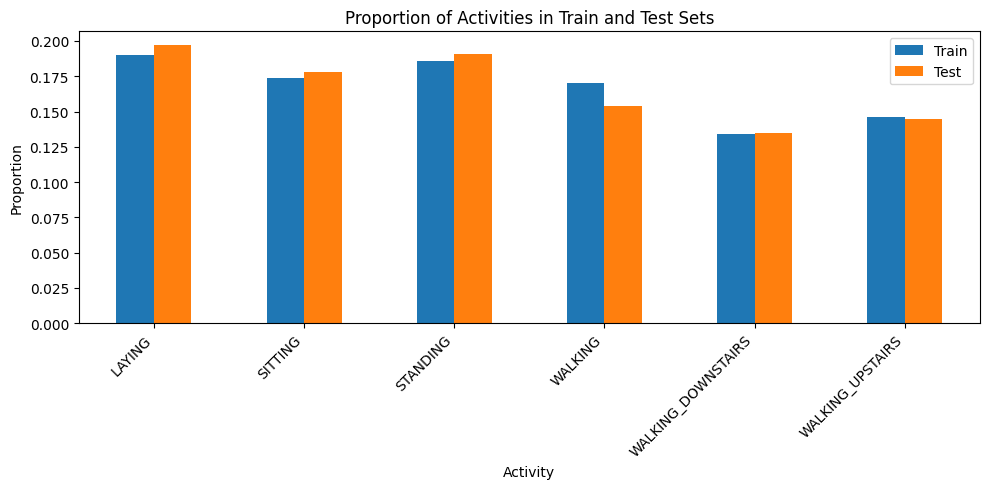

In [9]:
import matplotlib.pyplot as plt
activity_distrubution[["train_proportion", "test_proportion"]].plot(kind="bar", figsize=(10, 5))

plt.title("Proportion of Activities in Train and Test Sets")
plt.xlabel("Activity")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.legend(["Train", "Test"])
plt.tight_layout()
plt.show()